In [117]:
# =================================================================
# Bibliotheken importieren
# =================================================================

import os
import mysql.connector
import pandas as pd
import numpy as np

from pathlib import Path
from dotenv import load_dotenv
from sqlalchemy import create_engine
from urllib.parse import quote_plus

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [118]:
# =================================================================
# SQLAlchemy-Verbindung herstellen
# =================================================================

load_dotenv()

user = os.getenv("DB_USER")
password = os.getenv("DB_PASSWORD")
host = os.getenv("DB_HOST")
port = os.getenv("DB_PORT", "3306")
database = os.getenv("DB_NAME")

engine = create_engine(
    f"mysql+mysqlconnector://{user}:{quote_plus(password)}@{host}:{port}/{database}"
)

print("SQLAlchemy-Verbindung erfolgreich")

SQLAlchemy-Verbindung erfolgreich


In [ ]:
# ============================================================
# Anzahl der Zeilen für die zentralen ASHRAE-Tabellen prüfen
# ============================================================

tables = [
    "building_metadata",
    "train",
    "train_full",
    "weather_train"
]

for table in tables:
    anzahl_zeilen = pd.read_sql(
        f"SELECT COUNT(*) AS anzahl_zeilen FROM {table};",
        engine
    ).iloc[0, 0]

    print(f"{table}: {anzahl_zeilen}")

building_metadata: 1449
train: 20216100
train_full: 20216100
weather_train: 139773


Phase 1 – Exploration der Datenbankstruktur

Ziel: Die verfügbaren Tabellen und deren Struktur überprüfen,
ohne die ca.20 Millionen Datensätze vollständig in Python zu laden.

In [75]:
# =================================================================
# Phase 23.1 – Struktur der Datenbank
# Zweck: Überprüfung der vorhandenen Tabellen
# =================================================================

# Tabellen der Datenbank anzeigen
tables = pd.read_sql("SHOW TABLES;", engine)
print(tables)

  Tables_in_ashrae_energy
0       building_metadata
1                   train
2              train_full
3           weather_train


In [76]:
# =================================================================
# Phase 23.3 – Strukturen der relevanten Tabellen
# Zweck: Überprüfung der vorhandenen Tabellen
# =================================================================

structure_building = pd.read_sql(
    "DESCRIBE building_metadata;",
    engine
)

structure_weather = pd.read_sql(
    "DESCRIBE weather_train;",
   engine
)

structure_train_full = pd.read_sql(
    "DESCRIBE train_full;",
    engine
)

print("=== building_metadata ===")
print(structure_building)

print("\n=== weather_train ===")
print(structure_weather)

print("\n=== train_full ===")
print(structure_train_full)

=== building_metadata ===
         Field          Type Null  Key Default Extra
0      site_id           int  YES         None      
1  building_id           int  YES  MUL    None      
2  primary_use  varchar(100)  YES         None      
3  square_feet           int  YES         None      
4   year_built           int  YES         None      
5  floor_count           int  YES         None      

=== weather_train ===
                Field      Type Null  Key Default Extra
0             site_id       int  YES  MUL    None      
1           timestamp  datetime  YES         None      
2     air_temperature    double  YES         None      
3      cloud_coverage    double  YES         None      
4     dew_temperature    double  YES         None      
5   precip_depth_1_hr    double  YES         None      
6  sea_level_pressure    double  YES         None      
7      wind_direction    double  YES         None      
8          wind_speed    double  YES         None      

=== train_full ===


In [77]:
# =================================================================
# Phase 23.4 – Stichprobe der vorhandenen Daten
# Zweck: Kontrolle der tatsächlichen Dateninhalte
# =================================================================

train_sample = pd.read_sql(
    "SELECT * FROM train_full LIMIT 10;",
    engine
)

building_sample = pd.read_sql(
    "SELECT * FROM building_metadata LIMIT 10;",
    engine
)

weather_sample = pd.read_sql(
    "SELECT * FROM weather_train LIMIT 10;",
    engine
)

print("=== train_full ===")
print(train_sample)

print("\n=== building_metadata ===")
print(building_sample)

print("\n=== weather_train ===")
print(weather_sample)

=== train_full ===
   building_id  meter           timestamp  meter_reading  site_id primary_use  \
0            0      0 2016-01-01 00:00:00            0.0        0   Education   
1            0      0 2016-01-01 01:00:00            0.0        0   Education   
2            0      0 2016-01-01 02:00:00            0.0        0   Education   
3            0      0 2016-01-01 03:00:00            0.0        0   Education   
4            0      0 2016-01-01 04:00:00            0.0        0   Education   
5            0      0 2016-01-01 05:00:00            0.0        0   Education   
6            0      0 2016-01-01 06:00:00            0.0        0   Education   
7            0      0 2016-01-01 07:00:00            0.0        0   Education   
8            0      0 2016-01-01 08:00:00            0.0        0   Education   
9            0      0 2016-01-01 09:00:00            0.0        0   Education   

   square_feet  year_built floor_count  air_temperature  cloud_coverage  \
0         7432

In [78]:
# =================================================================
# Phase 24.1 – Zeitraum der Trainingsdaten
# Zweck: Bestimmung des verfügbaren Zeitraums
# =================================================================

zeitraum = pd.read_sql("""
    SELECT
        MIN(`timestamp`) AS zeitraum_beginn,
        MAX(`timestamp`) AS zeitraum_ende
    FROM train_full;
""", engine)

print(zeitraum)

  zeitraum_beginn       zeitraum_ende
0      2016-01-01 2016-12-31 23:00:00


In [79]:
# =================================================================
# Phase 24.2 – Zeitliche Stichprobe
# Zweck: Erstellung eines überschaubaren Trainingsdatensatzes
# =================================================================

train_sample = pd.read_sql("""
    SELECT *
    FROM train_full
    WHERE `timestamp` < '2016-04-01'
    LIMIT 100000;

""", engine)

print("Anzahl Datensätze:", len(train_sample))

Anzahl Datensätze: 100000


In [80]:
# =================================================================
# Phase 24.3 – Kontrolle der Stichprobe
# Zweck: Überprüfung des ausgewählten Datensatzes
# =================================================================

print(train_sample.shape)

print("\n=== Erste Datensätze ===")
print(train_sample.head())

print("\n=== Zeitraum ===")
print(
    train_sample["timestamp"].min(),
    "bis",
    train_sample["timestamp"].max()
) 

(100000, 16)

=== Erste Datensätze ===
   building_id  meter           timestamp  meter_reading  site_id primary_use  \
0            0      0 2016-01-01 00:00:00            0.0        0   Education   
1            0      0 2016-01-01 01:00:00            0.0        0   Education   
2            0      0 2016-01-01 02:00:00            0.0        0   Education   
3            0      0 2016-01-01 03:00:00            0.0        0   Education   
4            0      0 2016-01-01 04:00:00            0.0        0   Education   

   square_feet  year_built floor_count  air_temperature  cloud_coverage  \
0         7432        2008        None             25.0             6.0   
1         7432        2008        None             24.4             NaN   
2         7432        2008        None             22.8             2.0   
3         7432        2008        None             21.1             2.0   
4         7432        2008        None             20.0             2.0   

   dew_temperature  pre

In [81]:
# =================================================================
# Phase 24.4 – Fehlende Werte
# Zweck: Kontrolle der fehlenden Werte im Prototyp
# =================================================================

missing_values = train_sample.isnull().sum()

print(missing_values[missing_values > 0])

floor_count           100000
air_temperature          129
cloud_coverage         50828
dew_temperature          129
precip_depth_1_hr         43
sea_level_pressure      1024
wind_direction          1740
dtype: int64


Die Testdaten werden später für die Vorhersage vorbereitet.

test und weather_test sind derzeit noch nicht importiert.

– Analyze / Data

Phase 23 – Struktur und Stichproben 

Ziel: Datenbankstruktur prüfen und kleine Stichproben laden.

In [82]:
# =================================================================
# Phase 24 – Exploration der Daten
# Zweck: Erster Überblick über die Trainingsdaten
# =================================================================

query_sample = """
SELECT *
FROM train_full
LIMIT 500000;
"""

df = pd.read_sql(query_sample, engine)

print("Anzahl Datensätze:", len(df))

print("\nErste Zeilen:")
display(df.head())

print("\nInformationen zum DataFrame:")
df.info()

C:\Users\MamadouDianDiallo\AppData\Local\Temp\ipykernel_13776\3815515118.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query_sample, connection)


Anzahl Datensätze: 500000

Erste Zeilen:


,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,0,2016-01-01 00:00:00,0.0,0,Education,7432,2008,None,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
1,0,0,2016-01-01 01:00:00,0.0,0,Education,7432,2008,None,24.4,NaN,21.1,-1.0,1020.2,70.0,1.5
2,0,0,2016-01-01 02:00:00,0.0,0,Education,7432,2008,None,22.8,2.0,21.1,0.0,1020.2,0.0,0.0
3,0,0,2016-01-01 03:00:00,0.0,0,Education,7432,2008,None,21.1,2.0,20.6,0.0,1020.1,0.0,0.0
4,0,0,2016-01-01 04:00:00,0.0,0,Education,7432,2008,None,20.0,2.0,20.0,-1.0,1020.0,250.0,2.6



Informationen zum DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   building_id         500000 non-null  int64         
 1   meter               500000 non-null  int64         
 2   timestamp           500000 non-null  datetime64[us]
 3   meter_reading       500000 non-null  float64       
 4   site_id             500000 non-null  int64         
 5   primary_use         500000 non-null  str           
 6   square_feet         500000 non-null  int64         
 7   year_built          500000 non-null  int64         
 8   floor_count         0 non-null       object        
 9   air_temperature     499856 non-null  float64       
 10  cloud_coverage      282840 non-null  float64       
 11  dew_temperature     499856 non-null  float64       
 12  precip_depth_1_hr   499952 non-null  float64       
 13  sea_level_

In [83]:
# Überblick über fehlende Werte

print(df.isnull().sum())

building_id                0
meter                      0
timestamp                  0
meter_reading              0
site_id                    0
primary_use                0
square_feet                0
year_built                 0
floor_count           500000
air_temperature          144
cloud_coverage        217160
dew_temperature          144
precip_depth_1_hr         48
sea_level_pressure      4801
wind_direction         14505
wind_speed                 0
dtype: int64


In [84]:
# Statistische Übersicht der numerischen Variablen

print(df.describe())

         building_id          meter                   timestamp  \
count  500000.000000  500000.000000                      500000   
mean       23.816540       0.142558  2016-07-06 17:44:53.505599   
min         0.000000       0.000000         2016-01-01 00:00:00   
25%        12.000000       0.000000         2016-04-10 00:00:00   
50%        24.000000       0.000000         2016-07-07 10:00:00   
75%        35.000000       0.000000         2016-10-04 01:00:00   
max        49.000000       1.000000         2016-12-31 23:00:00   
std        13.971425       0.349622                         NaN   

       meter_reading   site_id    square_feet     year_built  air_temperature  \
count  500000.000000  500000.0  500000.000000  500000.000000    499856.000000   
mean      541.191392       0.0   63640.939444    1995.152964        23.065484   
min         0.000000       0.0     283.000000    1968.000000         1.700000   
25%         0.000000       0.0   24456.000000    1985.000000        19.4

Phase 25 – Deskriptive Analyse

Ziel: Die wichtigsten Eigenschaften des Energieverbrauchs untersuchen

In [85]:
# =================================================================
# Phase 25.1 – Energieverbrauch
# Zweck: Statistische Beschreibung des Energieverbrauchs
# =================================================================

print("Minimalverbrauch:", df["meter_reading"].min())
print("Maximalverbrauch:", df["meter_reading"].max())
print("Durchschnittlicher Verbrauch:", df["meter_reading"].mean())
print("Median:", df["meter_reading"].median())

Minimalverbrauch: 0.0
Maximalverbrauch: 10046.1
Durchschnittlicher Verbrauch: 541.1913919368
Median: 143.611


In [86]:
# =================================================================
# Phase 25.2 – Energieverbrauch nach Gebäudenutzung
# Zweck: Vergleich des Verbrauchs nach Gebäudetyp
# =================================================================

verbrauch_nutzung = (
    df.groupby("primary_use")["meter_reading"]
      .mean()
      .sort_values(ascending=False)
)

print(verbrauch_nutzung)

primary_use
Education                        904.360301
Entertainment/public assembly    579.635648
Other                            456.400861
Office                           347.950674
Lodging/residential              148.631567
Retail                            90.553544
Name: meter_reading, dtype: float64


Phase 26 – Zeitliche Analyse

Ziel: Die Entwicklung des Energieverbrauchs über die Zeit untersuchen.

Zuerst wandeln wir timestamp in ein echtes Datumsformat um.

In [88]:
# =================================================================
# Phase 26 – Zeitliche Analyse
# Zweck: Untersuchung der Verbrauchsentwicklung über die Zeit
# =================================================================

df["timestamp"] = pd.to_datetime(df["timestamp"])

df["datum"] = df["timestamp"].dt.date
df["stunde"] = df["timestamp"].dt.hour
df["monat"] = df["timestamp"].dt.month

In [89]:
# Durchschnittlicher Verbrauch pro Tag

verbrauch_tag = (
    df.groupby("datum")["meter_reading"]
      .mean()
)

print(verbrauch_tag.head())

datum
2016-01-01    1.317703
2016-01-02    1.315350
2016-01-03    1.100697
2016-01-04    1.224638
2016-01-05    1.065078
Name: meter_reading, dtype: float64


In [90]:
# Durchschnittlicher Verbrauch nach Stunde

verbrauch_stunde = (
    df.groupby("stunde")["meter_reading"]
      .mean()
)

print(verbrauch_stunde)

stunde
0     341.362932
1     334.000415
2     333.090929
3     332.004451
4     333.620389
5     370.259821
6     524.930319
7     575.165915
8     587.891278
9     629.408809
10    658.238795
11    675.090039
12    679.660346
13    684.792866
14    688.552916
15    685.981327
16    677.646680
17    657.586815
18    637.077577
19    617.319497
20    594.988800
21    553.572432
22    467.678395
23    347.102865
Name: meter_reading, dtype: float64


Phase 27 – Gebäudeanalyse

Ziel: Gebäude mit besonders hohem Energieverbrauch identifizieren.

In [91]:
# =================================================================
# Phase 27.1 – Gebäude mit hohem Verbrauch
# Zweck: Identifikation der Gebäude mit dem höchsten Gesamtverbrauch
# =================================================================

top_gebaeude = (
    df.groupby(["building_id", "primary_use"])["meter_reading"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_gebaeude)

building_id  primary_use                  
29           Education                        3.424574e+07
7            Education                        2.558355e+07
31           Education                        2.533426e+07
30           Education                        2.343710e+07
14           Education                        2.060938e+07
15           Office                           1.622311e+07
13           Education                        1.593804e+07
18           Education                        1.096506e+07
28           Office                           9.890082e+06
10           Entertainment/public assembly    8.616652e+06
Name: meter_reading, dtype: float64


In [92]:
# =================================================================
# Phase 27.2 – Energieverbrauch pro Fläche
# Zweck: Vergleich des Verbrauchs unter Berücksichtigung
#        der Gebäudegröße
# =================================================================

df_area = df[df["square_feet"] > 0].copy()

verbrauch_flaeche = (
    df_area.groupby(["building_id", "primary_use", "square_feet"])
           ["meter_reading"]
           .sum()
           .reset_index()
)

verbrauch_flaeche["verbrauch_pro_flaeche"] = (
    verbrauch_flaeche["meter_reading"]
    / verbrauch_flaeche["square_feet"]
)

print(
    verbrauch_flaeche
    .sort_values("verbrauch_pro_flaeche", ascending=False)
    .head(10)
)

    building_id primary_use  square_feet  meter_reading  verbrauch_pro_flaeche
31           31   Education        61904   2.533426e+07             409.250848
29           29   Education       113866   3.424574e+07             300.754737
30           30   Education        93897   2.343710e+07             249.604325
1             1   Education         2720   6.576176e+05             241.771181
14           14   Education        86250   2.060938e+07             238.949278
44           44      Retail          283   6.301221e+04             222.657996
7             7   Education       121074   2.558355e+07             211.305083
38           38      Office        12769   2.647768e+06             207.359105
9             9      Office        27000   5.468687e+06             202.543964
15           15      Office        83957   1.622311e+07             193.231176


In [93]:
# =================================================================
# Phase 28 – Wetteranalyse
# Zweck: Untersuchung des Zusammenhangs zwischen Temperatur
#        und Energieverbrauch
# =================================================================

df_weather = df.dropna(
    subset=["air_temperature", "meter_reading"]
).copy()

In [94]:
temperatur_verbrauch = (
    df_weather.groupby("air_temperature")["meter_reading"]
              .mean()
              .reset_index()
)

print(temperatur_verbrauch.head())

   air_temperature  meter_reading
0              1.7       0.072522
1              2.2       0.072522
2              2.8       0.705313
3              3.3       0.488457
4              3.9       0.924520


Korrelation : 
Wichtig: Eine Korrelation zeigt einen statistischen Zusammenhang. Sie beweist nicht automatisch einen kausalen Einfluss.

In [95]:
# Korrelation zwischen Außentemperatur und Energieverbrauch

korrelation = df_weather[
    ["air_temperature", "meter_reading"]
].corr()

print(korrelation)

                 air_temperature  meter_reading
air_temperature         1.000000       0.197768
meter_reading           0.197768       1.000000


Phase 29 – Visualisierung

Ziel: Die wichtigsten Ergebnisse grafisch darstellen.

Wir erstellen nur die wichtigsten Visualisierungen, damit das Projekt übersichtlich bleibt.

In [96]:
# =================================================================
# Phase 29 – Visualisierung
# Zweck: Darstellung der wichtigsten Ergebnisse der Datenanalyse
# =================================================================

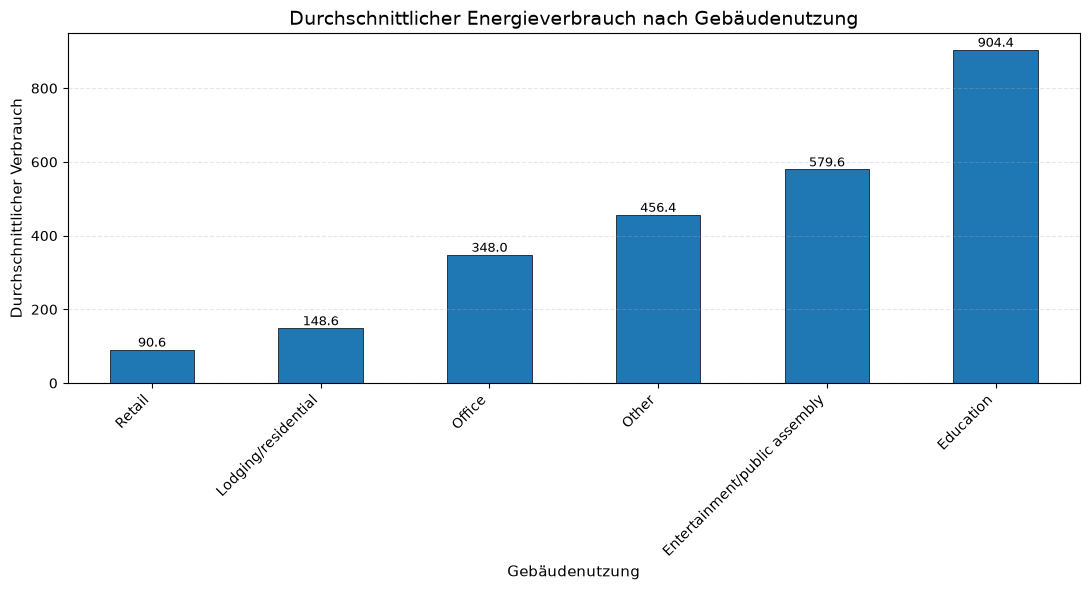

In [97]:
# =================================================================
# Phase 29.1 – Verbrauch nach Gebäudenutzung
# Zweck: Vergleich des durchschnittlichen Energieverbrauchs
#        nach Gebäudenutzung
# =================================================================

from matplotlib import pyplot as plt


verbrauch_sorted = verbrauch_nutzung.sort_values()

plt.figure(figsize=(11, 6))

ax = verbrauch_sorted.plot(
    kind="bar",
    edgecolor="black",
    linewidth=0.5
)

plt.title("Durchschnittlicher Energieverbrauch nach Gebäudenutzung", fontsize=14)
plt.xlabel("Gebäudenutzung", fontsize=11)
plt.ylabel("Durchschnittlicher Verbrauch", fontsize=11)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.3)

for i, wert in enumerate(verbrauch_sorted):
    ax.text(i, wert, f"{wert:.1f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

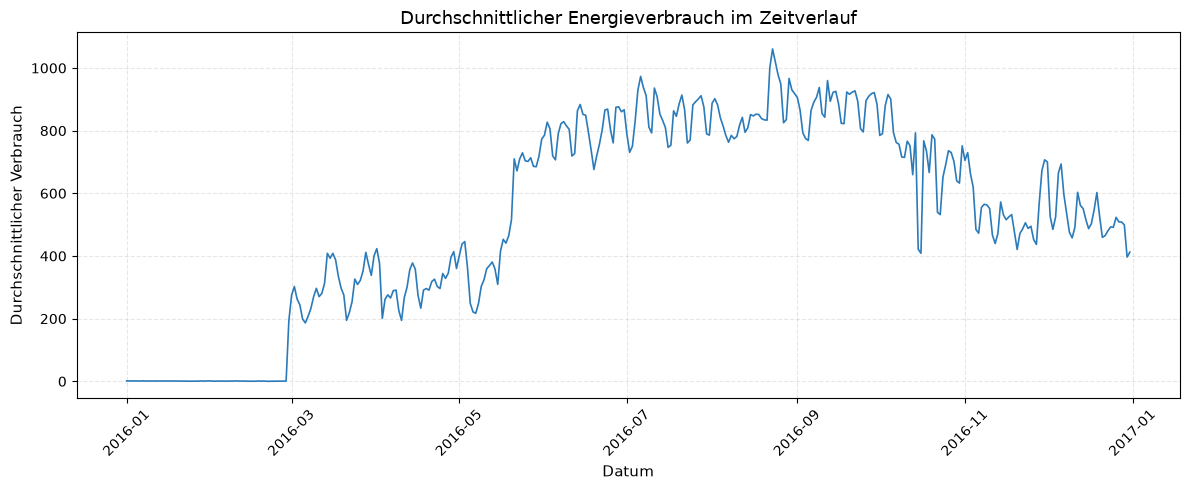

In [98]:
# =================================================================
# Phase 29.2 – Zeitliche Entwicklung
# Zweck: Darstellung der Verbrauchsentwicklung über die Zeit
# =================================================================

plt.figure(figsize=(12, 5))

plt.plot(
    verbrauch_tag.index,
    verbrauch_tag.values,
    color="#2b7bba",
    linewidth=1.2
)

plt.title(
    "Durchschnittlicher Energieverbrauch im Zeitverlauf",
    fontsize=13
)

plt.xlabel("Datum", fontsize=11)
plt.ylabel("Durchschnittlicher Verbrauch", fontsize=11)

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

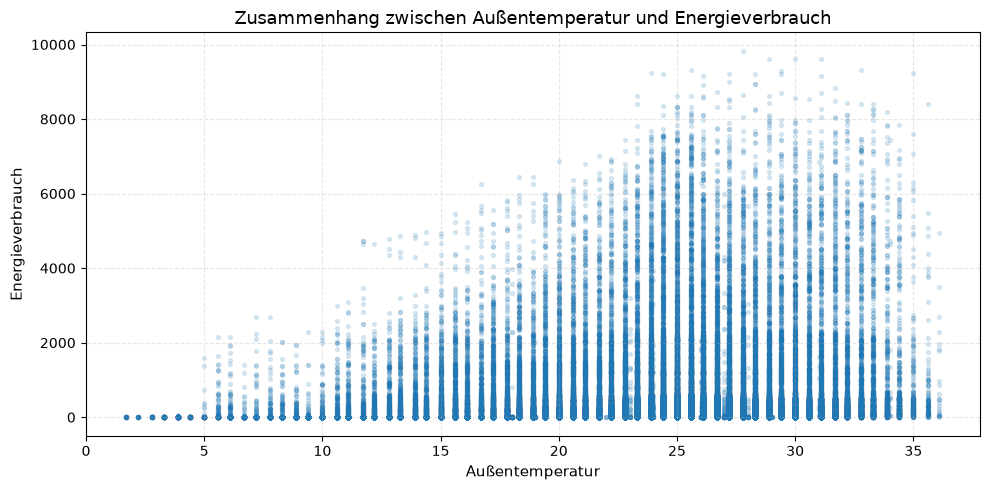

In [99]:
# =================================================================
# Phase 29.3 – Temperatur und Energieverbrauch
# Zweck: Untersuchung des Zusammenhangs zwischen Außentemperatur
#     und Energieverbrauch
# =================================================================

df_plot = df_weather[
    ["air_temperature", "meter_reading"]
].dropna()

df_plot = df_plot.sample(
    n=min(100000, len(df_plot)),
    random_state=42
)

plt.figure(figsize=(10, 5))

plt.scatter(
    df_plot["air_temperature"],
    df_plot["meter_reading"],
    alpha=0.15,
    s=8
)

plt.title(
    "Zusammenhang zwischen Außentemperatur und Energieverbrauch",
    fontsize=13
)

plt.xlabel("Außentemperatur", fontsize=11)
plt.ylabel("Energieverbrauch", fontsize=11)

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

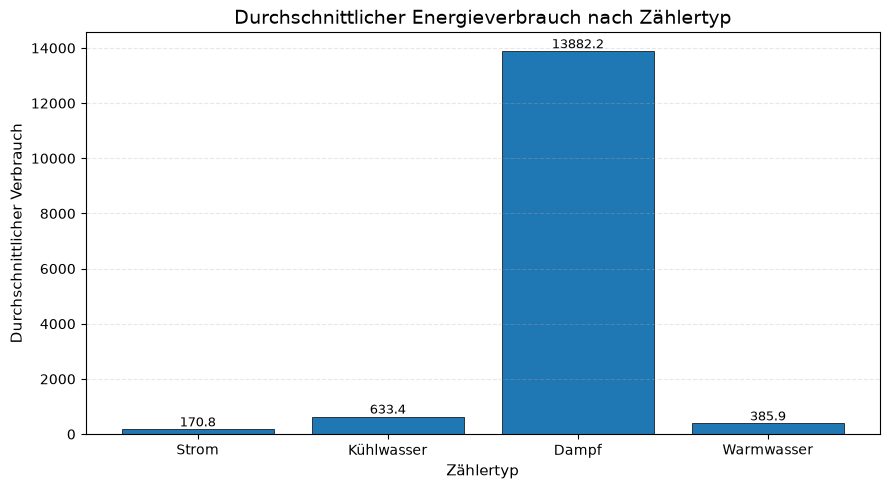

In [107]:
# =================================================================
# Phase 29.4 – Verbrauch nach Zählertyp
# Zweck: Vergleich des durchschnittlichen Energieverbrauchs
#        nach Zählertyp
# =================================================================

verbrauch_meter = pd.read_sql(
    """
    SELECT
        meter,
        AVG(meter_reading) AS durchschnittlicher_verbrauch
    FROM train_full
    GROUP BY meter
    ORDER BY meter;
    """,
    engine
)

# Mapping der ASHRAE-Zählertypen
meter_namen = {
    0: "Strom",
    1: "Kühlwasser",
    2: "Dampf",
    3: "Warmwasser"
}

verbrauch_meter["meter_label"] = (
    verbrauch_meter["meter"].map(meter_namen)
)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    verbrauch_meter["meter_label"],
    verbrauch_meter["durchschnittlicher_verbrauch"],
    edgecolor="black",
    linewidth=0.5
)

plt.title(
    "Durchschnittlicher Energieverbrauch nach Zählertyp",
    fontsize=14
)

plt.xlabel("Zählertyp", fontsize=11)
plt.ylabel("Durchschnittlicher Verbrauch", fontsize=11)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

for bar in bars:
    wert = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        wert,
        f"{wert:.1f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()


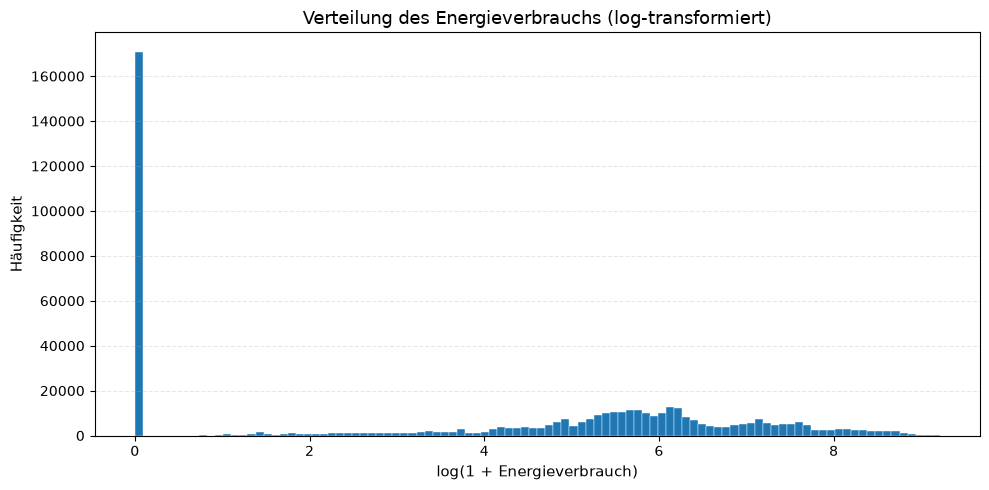

In [102]:
# =================================================================
# Phase 29.5 – Verteilung des Energieverbrauchs
# Zweck: Untersuchung der Verbrauchsverteilung und extremer Werte
# =================================================================

consommation_log = np.log1p(df["meter_reading"])

plt.figure(figsize=(10, 5))

plt.hist(
    consommation_log,
    bins=100,
    edgecolor="white",
    linewidth=0.3
)

plt.title("Verteilung des Energieverbrauchs (log-transformiert)", fontsize=13)
plt.xlabel("log(1 + Energieverbrauch)", fontsize=11)
plt.ylabel("Häufigkeit", fontsize=11)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()